In [2]:
import sys
sys.path.insert(0, '../src/models')
sys.path.insert(0, '../src/evaluation')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
import pickle
import mlflow

import uncertainty

print("All imports successful")

All imports successful


In [3]:
GLOBAL_MODEL_PATH = '../models/global_model.pkl'
PROCESSED_DIR = '../data/processed'

calibration_stats = uncertainty.calibrate(
    global_model_path=GLOBAL_MODEL_PATH,
    processed_dir=PROCESSED_DIR,
    site_encoding=2,
    train_frac=0.70,
)

print("\nCalibration stats:")
for k, v in calibration_stats.items():
    print(f"  {k}: {v}")

Global model loaded from ../models/global_model.pkl
Loaded 8 office001 stations.
  office001_19-102-260-1633: 9359 calibration rows, mean residual = 0.0491
  office001_19-102-260-1634: 9665 calibration rows, mean residual = 0.0333
  office001_19-102-260-1635: 9980 calibration rows, mean residual = 0.0259
  office001_19-102-260-1636: 8759 calibration rows, mean residual = 0.0419
  office001_19-102-260-1637: 7009 calibration rows, mean residual = 0.0200
  office001_19-102-260-1638: 5551 calibration rows, mean residual = 0.0272
  office001_19-102-260-1639: 10369 calibration rows, mean residual = 0.0266
  office001_19-102-260-1640: 10623 calibration rows, mean residual = 0.0528

  Zero-regime hours:    61,435 (86.1%)
  Non-zero-regime hours: 9,880 (13.9%)

Calibration complete.
  Total conformity scores:     71,315

  Single quantile approach:
    q80: 0.0004 sessions
    q90: 0.0200 sessions

  Conditional quantile approach:
    q80_zero:    0.0000 sessions
    q90_zero:    0.0004 session

In [4]:
print("=== Single quantile approach ===")
coverage_single = uncertainty.evaluate_coverage(
    global_model_path=GLOBAL_MODEL_PATH,
    processed_dir=PROCESSED_DIR,
    site_encoding=2,
    train_frac=0.70,
    method="single",
)
print(coverage_single.to_string(index=False))

print("\n=== Conditional quantile approach ===")
coverage_conditional = uncertainty.evaluate_coverage(
    global_model_path=GLOBAL_MODEL_PATH,
    processed_dir=PROCESSED_DIR,
    site_encoding=2,
    train_frac=0.70,
    method="conditional",
)
print(coverage_conditional.to_string(index=False))

=== Single quantile approach ===
Loaded 8 office001 stations.
  office001_19-102-260-1633: coverage_80=0.992, coverage_90=0.997
  office001_19-102-260-1634: coverage_80=0.969, coverage_90=0.992
  office001_19-102-260-1635: coverage_80=0.986, coverage_90=0.996
  office001_19-102-260-1636: coverage_80=0.987, coverage_90=0.993
  office001_19-102-260-1637: coverage_80=0.992, coverage_90=0.998
  office001_19-102-260-1638: coverage_80=0.832, coverage_90=0.927
  office001_19-102-260-1639: coverage_80=0.766, coverage_90=0.883
  office001_19-102-260-1640: coverage_80=0.743, coverage_90=0.862
               station_id  eval_rows  coverage_80  coverage_90  gap_80  gap_90
office001_19-102-260-1633       4083       0.9919       0.9971  0.1919  0.0971
office001_19-102-260-1634       4215       0.9692       0.9919  0.1692  0.0919
office001_19-102-260-1635       4350       0.9860       0.9963  0.1860  0.0963
office001_19-102-260-1636       3826       0.9872       0.9932  0.1872  0.0932
office001_19-10

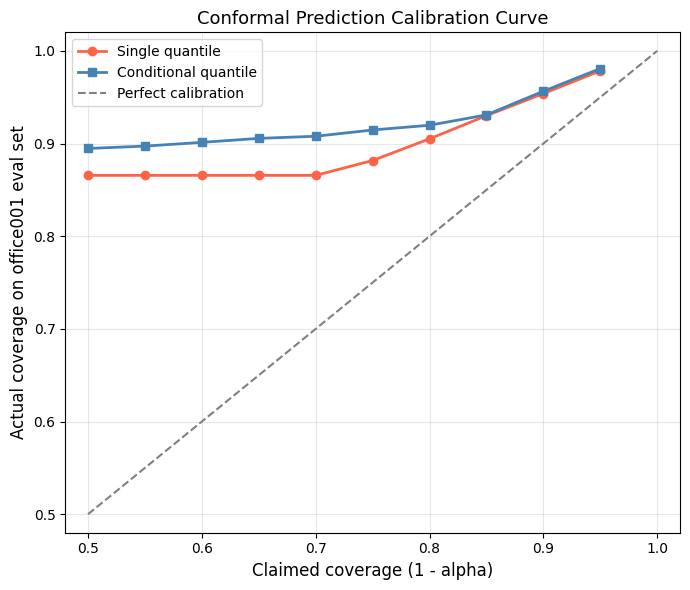

Saved to reports/calibration_curve.png


In [6]:
with open(GLOBAL_MODEL_PATH, 'rb') as f:
    booster = pickle.load(f)

# ── Build calibration predictions to get correct regime masks ──────────────
# _residuals comes from the calibration split (71,315 rows)
# We need a mask of the same length to split it by regime
calib_frames = []
files = sorted(glob.glob('../data/processed/office001_*.parquet'))

for f in files:
    df = pd.read_parquet(f)
    if 'site_encoded' not in df.columns:
        df['site_encoded'] = 2
    df = df.sort_values('timestamp').reset_index(drop=True)
    cutoff = int(len(df) * 0.70)
    calib_df = df.iloc[:cutoff].dropna(subset=uncertainty.FEATURE_COLS + ['sessions'])
    calib_frames.append(calib_df)

calib_all = pd.concat(calib_frames, ignore_index=True)
y_pred_calib = booster.predict(calib_all[uncertainty.FEATURE_COLS].values)

# ── Build evaluation predictions for coverage check ───────────────────────
eval_frames = []
for f in files:
    df = pd.read_parquet(f)
    if 'site_encoded' not in df.columns:
        df['site_encoded'] = 2
    df = df.sort_values('timestamp').reset_index(drop=True)
    cutoff = int(len(df) * 0.70)
    eval_df = df.iloc[cutoff:].dropna(subset=uncertainty.FEATURE_COLS + ['sessions'])
    eval_frames.append(eval_df)

eval_all = pd.concat(eval_frames, ignore_index=True)
X_eval = eval_all[uncertainty.FEATURE_COLS].values
y_true_all = eval_all['sessions'].values
y_pred_all = booster.predict(X_eval)
residuals_eval = np.abs(y_true_all - y_pred_all)

# ── Sweep alpha levels ─────────────────────────────────────────────────────
alphas = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
claimed_coverages = [1 - a for a in alphas]

actual_coverages_single = []
actual_coverages_conditional = []

for alpha in alphas:
    n = len(uncertainty._residuals)
    q_level = min((1 - alpha) * (1 + 1/n), 1.0)

    # Single quantile — one value for all predictions
    q_single = float(np.quantile(uncertainty._residuals, q_level))
    covered_single = float(np.mean(residuals_eval <= q_single))
    actual_coverages_single.append(covered_single)

    # Conditional quantile — split calibration residuals by regime
    calib_zero_mask = y_pred_calib < uncertainty.NONZERO_THRESHOLD
    calib_nonzero_mask = ~calib_zero_mask

    residuals_zero = uncertainty._residuals[calib_zero_mask]
    residuals_nonzero = uncertainty._residuals[calib_nonzero_mask]

    q_zero = float(np.quantile(residuals_zero, q_level)) if len(residuals_zero) > 0 else 0.0
    q_nonzero = float(np.quantile(residuals_nonzero, q_level)) if len(residuals_nonzero) > 0 else q_single

    # Apply correct quantile to each eval prediction based on its regime
    eval_zero_mask = y_pred_all < uncertainty.NONZERO_THRESHOLD
    q_conditional = np.where(eval_zero_mask, q_zero, q_nonzero)
    covered_conditional = float(np.mean(residuals_eval <= q_conditional))
    actual_coverages_conditional.append(covered_conditional)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(claimed_coverages, actual_coverages_single,
        marker='o', linewidth=2, color='tomato', label='Single quantile')
ax.plot(claimed_coverages, actual_coverages_conditional,
        marker='s', linewidth=2, color='steelblue', label='Conditional quantile')
ax.plot([0.5, 1.0], [0.5, 1.0],
        linestyle='--', color='gray', linewidth=1.5, label='Perfect calibration')

ax.set_xlabel('Claimed coverage (1 - alpha)', fontsize=12)
ax.set_ylabel('Actual coverage on office001 eval set', fontsize=12)
ax.set_title('Conformal Prediction Calibration Curve', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0.48, 1.02)
ax.set_ylim(0.48, 1.02)

plt.tight_layout()
plt.savefig('../reports/calibration_curve.png', dpi=150)
plt.show()
print("Saved to reports/calibration_curve.png")

In [9]:
# Use the busiest station (1640) for the most informative plot
sample_file = sorted(glob.glob('../data/processed/office001_*.parquet'))[7]
df_sample = pd.read_parquet(sample_file)

if 'site_encoded' not in df_sample.columns:
    df_sample['site_encoded'] = 2

df_sample = df_sample.sort_values('timestamp').reset_index(drop=True)
cutoff = int(len(df_sample) * 0.70)
eval_sample = df_sample.iloc[cutoff:].dropna(
    subset=uncertainty.FEATURE_COLS + ['sessions']
)

# Find a 72-hour window with meaningful activity (at least 8 sessions)
window_size = 72
eval_window = None

for start_idx in range(0, len(eval_sample) - window_size, 24):
    window = eval_sample.iloc[start_idx : start_idx + window_size]
    if window['sessions'].sum() >= 8:
        eval_window = window
        print(f"Active window found:")
        print(f"  From: {window['timestamp'].iloc[0]}")
        print(f"  To:   {window['timestamp'].iloc[-1]}")
        print(f"  Total sessions: {window['sessions'].sum():.1f}")
        break

if eval_window is None:
    raise ValueError("No sufficiently active window found in station 1640 eval period.")

X_sample = eval_window[uncertainty.FEATURE_COLS].values
y_pred_sample = booster.predict(X_sample)

forecast_df = uncertainty.predict_with_intervals(y_pred_sample, method="conditional")

# Clip point_estimate at zero — LightGBM can produce tiny negatives
forecast_df['point_estimate'] = forecast_df['point_estimate'].clip(lower=0)
forecast_df['timestamp'] = eval_window['timestamp'].values
forecast_df['actual'] = eval_window['sessions'].values

cols = ['timestamp', 'actual', 'point_estimate', 'lower_80', 'upper_80', 'lower_90', 'upper_90']
print(forecast_df[cols].to_string(index=False))

Active window found:
  From: 2020-06-20 05:00:00-07:00
  To:   2020-06-23 04:00:00-07:00
  Total sessions: 11.0
          timestamp  actual  point_estimate  lower_80  upper_80  lower_90  upper_90
2020-06-20 12:00:00       0        0.000000  0.000000  0.000000  0.000000  0.000373
2020-06-20 13:00:00       0        0.000000  0.000000  0.000000  0.000000  0.000373
2020-06-20 14:00:00       0        0.000000  0.000000  0.000000  0.000000  0.000373
2020-06-20 15:00:00       0        0.000000  0.000000  0.000000  0.000000  0.000373
2020-06-20 16:00:00       0        0.000000  0.000000  0.000000  0.000000  0.000373
2020-06-20 17:00:00       0        0.000000  0.000000  0.000000  0.000000  0.000373
2020-06-20 18:00:00       0        0.000000  0.000000  0.000000  0.000000  0.000373
2020-06-20 19:00:00       0        0.000000  0.000000  0.000000  0.000000  0.000373
2020-06-20 20:00:00       0        0.000000  0.000000  0.000000  0.000000  0.000373
2020-06-20 21:00:00       0        0.000000  0.0

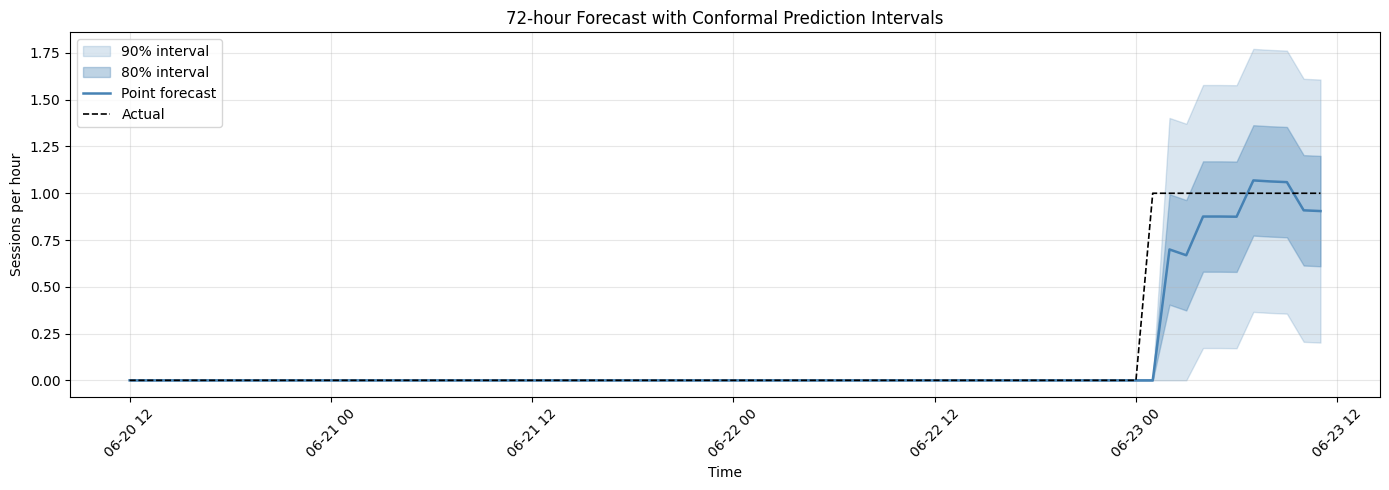

Saved to reports/forecast_with_intervals.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

timestamps = pd.to_datetime(forecast_df['timestamp'])

ax.fill_between(timestamps, forecast_df['lower_90'], forecast_df['upper_90'],
                alpha=0.20, color='steelblue', label='90% interval')
ax.fill_between(timestamps, forecast_df['lower_80'], forecast_df['upper_80'],
                alpha=0.35, color='steelblue', label='80% interval')
ax.plot(timestamps, forecast_df['point_estimate'],
        color='steelblue', linewidth=1.8, label='Point forecast')
ax.plot(timestamps, forecast_df['actual'],
        color='black', linewidth=1.2, linestyle='--', label='Actual')

ax.set_xlabel('Time')
ax.set_ylabel('Sessions per hour')
ax.set_title('72-hour Forecast with Conformal Prediction Intervals')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/forecast_with_intervals.png', dpi=150)
plt.show()
print("Saved to reports/forecast_with_intervals.png")

In [11]:
mlflow.set_tracking_uri("http://localhost:5000")
uncertainty.log_to_mlflow(calibration_stats, coverage_single, coverage_conditional)
print("Done.")

2026/05/28 11:08:09 INFO mlflow.tracking.fluent: Experiment with name 'phase5_uncertainty' does not exist. Creating a new experiment.


Results logged to MLflow experiment: phase5_uncertainty
Done.
